# 🗄️ Customer Churn — SQL Analysis

> **Goal:** Answer 10 business questions using SQL against a SQLite database

---
### 📋 Table of Contents
1. [Setup & Connect to DB](#1)
2. [Q1 — Overall Churn Rate](#2)
3. [Q2 — Churn by Contract Type](#3)
4. [Q3 — Churn by Tenure](#4)
5. [Q4 — Revenue at Risk](#5)
6. [Q5 — Churn by Payment Method](#6)
7. [Q6 — Internet Service + Tech Support](#7)
8. [Q7 — High Risk Segments](#8)
9. [Q8 — Churn by Number of Services](#9)
10. [Q9 — Demographics](#10)
11. [Q10 — Executive Summary](#11)

## 1. Setup & Connect to Database <a id='1'></a>

In [3]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import os

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.2)
plt.rcParams['figure.dpi'] = 120

DB_PATH = '../data/churn.db'

# Helper: run any SQL file and return a DataFrame
def run_query(sql_file=None, sql=None):
    conn = sqlite3.connect(DB_PATH)
    if sql_file:
        with open(sql_file, 'r', encoding='utf-8') as f:
            # Strip comments for execution
            raw = f.read()
            sql = '\n'.join(
                line for line in raw.splitlines()
                if not line.strip().startswith('--')
            )
    df = pd.read_sql_query(sql, conn)
    conn.close()
    return df

# Verify DB exists
if os.path.exists(DB_PATH):
    print('✅ Database connected:', DB_PATH)
    df_check = run_query(sql='SELECT COUNT(*) AS total_rows FROM customers')
    print(f'   Rows in customers table: {df_check["total_rows"][0]:,}')
else:
    print('❌ DB not found! Run: python src/setup_database.py')

✅ Database connected: ../data/churn.db
   Rows in customers table: 7,043


## Q1 — Overall Churn Rate <a id='2'></a>

In [4]:
df1 = run_query('../queries/01_overall_churn_rate.sql')
display(df1)

print(f"""
📌 Key Insight:
   Out of {df1['total_customers'][0]:,} customers,
   {df1['churned_customers'][0]:,} have churned ({df1['churn_rate_pct'][0]}% churn rate).
   That means 1 in every 4 customers is leaving.
""")

,total_customers,churned_customers,retained_customers,churn_rate_pct,retention_rate_pct
0,7043,1869,5174,26.54,73.46



📌 Key Insight:
   Out of 7,043 customers,
   1,869 have churned (26.54% churn rate).
   That means 1 in every 4 customers is leaving.



## Q2 — Churn by Contract Type <a id='3'></a>

,contract_type,total_customers,churned,churn_rate_pct,avg_monthly_charge
0,Month-to-month,3875,1655,42.71,66.40
1,One year,1473,166,11.27,65.05
2,Two year,1695,48,2.83,60.77


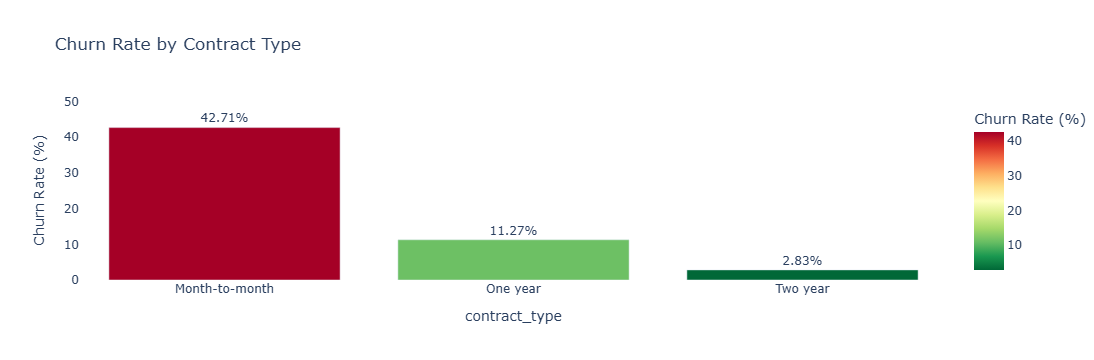

📌 Insight: Month-to-month customers churn at 3x the rate of annual plan customers.


In [5]:
df2 = run_query('../queries/02_churn_by_contract.sql')
display(df2)

fig = px.bar(df2, x='contract_type', y='churn_rate_pct',
             color='churn_rate_pct', color_continuous_scale='RdYlGn_r',
             title='Churn Rate by Contract Type',
             text='churn_rate_pct', labels={'churn_rate_pct': 'Churn Rate (%)'})
fig.update_traces(texttemplate='%{text}%', textposition='outside')
fig.update_layout(showlegend=False, plot_bgcolor='white')
fig.show()

print('📌 Insight: Month-to-month customers churn at 3x the rate of annual plan customers.')

## Q3 — Churn by Tenure Group <a id='4'></a>

,tenure_group,total_customers,churned,churn_rate_pct,avg_monthly_charge,avg_total_revenue
0,0-12 months,2186,1037,47.44,56.10,275.23
1,12-24 months,1024,294,28.71,61.36,1126.26
2,24-48 months,1594,325,20.39,65.93,2390.45
3,48-72 months,2239,213,9.51,73.95,4685.51


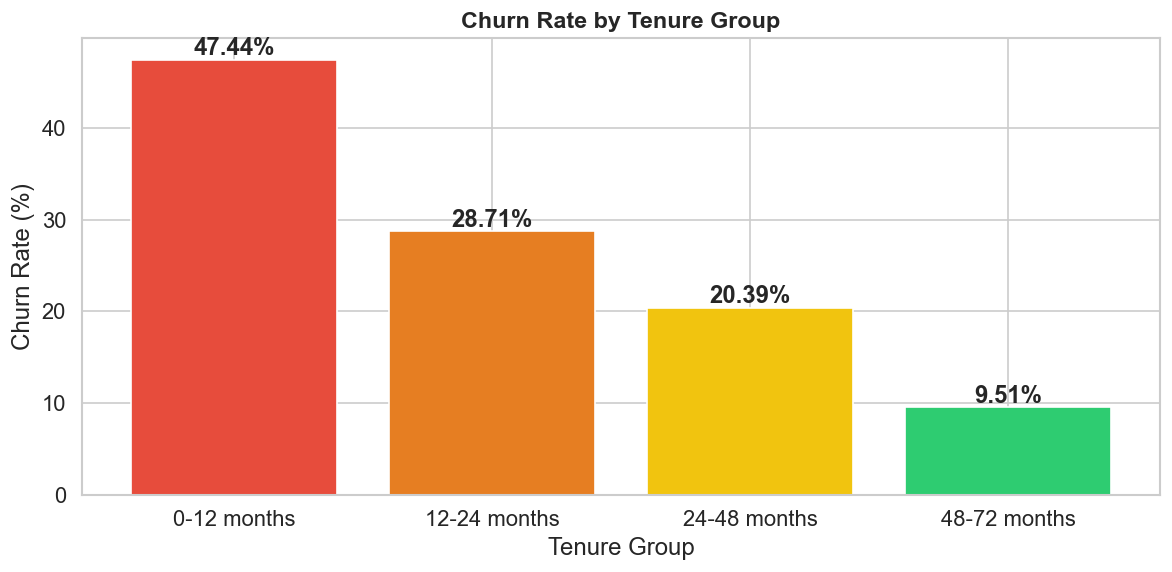

📌 Insight: Newest customers (0-12 months) are the highest risk group.


In [6]:
df3 = run_query('../queries/03_churn_by_tenure.sql')
display(df3)

colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71']
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(df3['tenure_group'], df3['churn_rate_pct'], color=colors, edgecolor='white')
ax.set_title('Churn Rate by Tenure Group', fontsize=14, fontweight='bold')
ax.set_xlabel('Tenure Group')
ax.set_ylabel('Churn Rate (%)')
for bar, val in zip(bars, df3['churn_rate_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/sql_churn_by_tenure.png', bbox_inches='tight')
plt.show()
print('📌 Insight: Newest customers (0-12 months) are the highest risk group.')

## Q4 — Revenue at Risk <a id='5'></a>

,monthly_revenue_lost,monthly_revenue_retained,total_monthly_revenue,pct_revenue_at_risk,avg_charge_churned,avg_charge_retained
0,139130.85,316985.75,456116.6,30.5,74.44,61.27


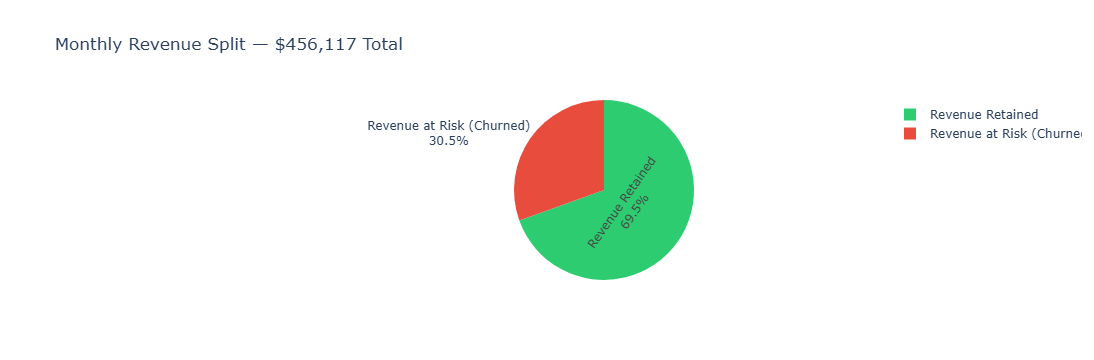

📌 Insight: $139,131/month at risk.
   Churned customers pay $74.44 avg vs $61.27 for retained.
   High-value customers are leaving more than low-value ones!


In [7]:
df4 = run_query('../queries/04_revenue_at_risk.sql')
display(df4)

# Revenue breakdown pie
labels = ['Revenue Retained', 'Revenue at Risk (Churned)']
values = [df4['monthly_revenue_retained'][0], df4['monthly_revenue_lost'][0]]
fig = px.pie(values=values, names=labels,
             color_discrete_sequence=['#2ecc71', '#e74c3c'],
             title=f'Monthly Revenue Split — ${df4["total_monthly_revenue"][0]:,.0f} Total')
fig.update_traces(textinfo='percent+label')
fig.show()

print(f'📌 Insight: ${df4["monthly_revenue_lost"][0]:,.0f}/month at risk.')
print(f'   Churned customers pay ${df4["avg_charge_churned"][0]} avg vs ${df4["avg_charge_retained"][0]} for retained.')
print('   High-value customers are leaving more than low-value ones!')

## Q5 — Churn by Payment Method <a id='6'></a>

,payment_method,total_customers,churned,churn_rate_pct,avg_monthly_charge
0,Electronic check,2365,1071,45.29,76.26
1,Mailed check,1612,308,19.11,43.92
2,Bank transfer (automatic),1544,258,16.71,67.19
3,Credit card (automatic),1522,232,15.24,66.51


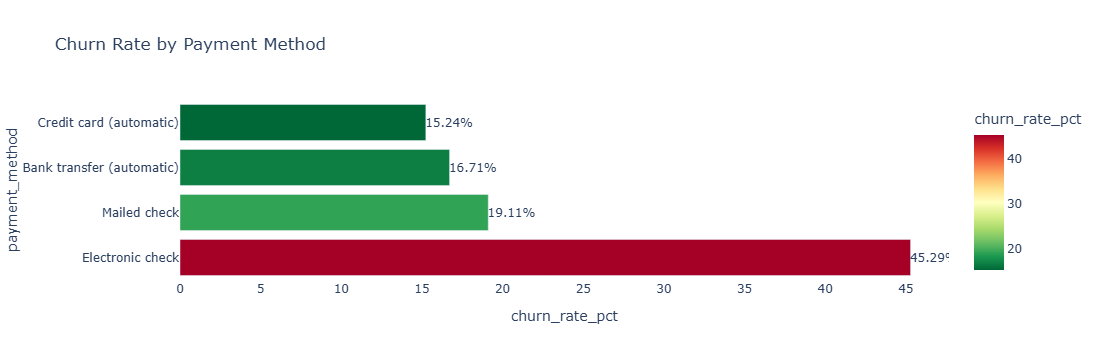

📌 Insight: Electronic check users churn at nearly 3x the rate of auto-pay users.


In [8]:
df5 = run_query('../queries/05_churn_by_payment.sql')
display(df5)

fig = px.bar(df5, x='churn_rate_pct', y='payment_method', orientation='h',
             color='churn_rate_pct', color_continuous_scale='RdYlGn_r',
             title='Churn Rate by Payment Method',
             text='churn_rate_pct')
fig.update_traces(texttemplate='%{text}%', textposition='outside')
fig.update_layout(showlegend=False, plot_bgcolor='white')
fig.show()
print('📌 Insight: Electronic check users churn at nearly 3x the rate of auto-pay users.')

## Q6 — Internet Service + Tech Support <a id='7'></a>

,internet_service,tech_support,total_customers,churned,churn_rate_pct,avg_monthly_charge
0,Fiber optic,No,2230,1101,49.37,87.74
1,DSL,No,1243,345,27.76,50.98
2,Fiber optic,Yes,866,196,22.63,101.18
3,DSL,Yes,1178,114,9.68,65.61
4,No,No,1526,113,7.40,21.08


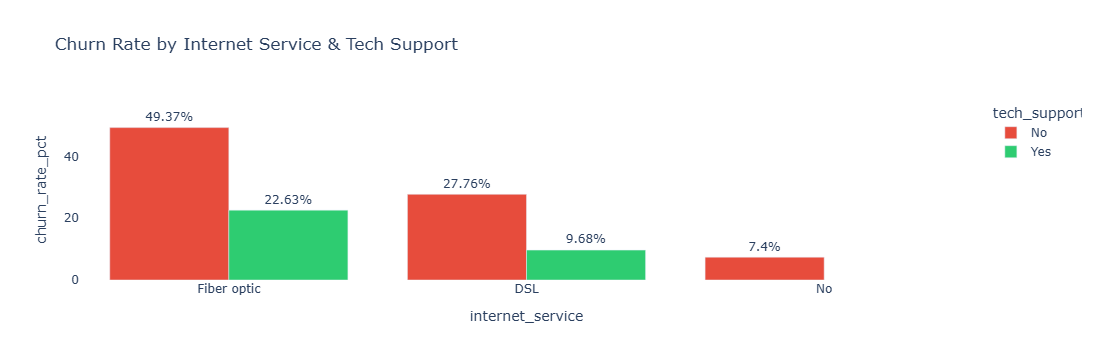

📌 Insight: Tech Support cuts churn by more than half for Fiber Optic customers.


In [9]:
df6 = run_query('../queries/06_churn_by_internet_techsupport.sql')
display(df6)

fig = px.bar(df6, x='internet_service', y='churn_rate_pct',
             color='tech_support', barmode='group',
             title='Churn Rate by Internet Service & Tech Support',
             color_discrete_map={'Yes': '#2ecc71', 'No': '#e74c3c'},
             text='churn_rate_pct')
fig.update_traces(texttemplate='%{text}%', textposition='outside')
fig.update_layout(plot_bgcolor='white')
fig.show()
print('📌 Insight: Tech Support cuts churn by more than half for Fiber Optic customers.')

## Q7 — High Risk Segments (Retention Hit List) <a id='8'></a>

In [10]:
df7 = run_query('../queries/07_high_risk_segments.sql')
print('🎯 Top 10 Highest-Risk Customer Segments (Retention Hit List):')
display(df7.style.background_gradient(subset=['churn_rate_pct'], cmap='RdYlGn_r'))
print('📌 These are the exact customer groups the retention team should target first.')

🎯 Top 10 Highest-Risk Customer Segments (Retention Hit List):


,contract_type,tenure_group,payment_method,internet_service,tech_support,segment_size,already_churned,churn_rate_pct,avg_monthly_charge,est_revenue_at_risk
0,Month-to-month,0-12 months,Bank transfer (automatic),Fiber optic,No,76,63,82.890000,81.480000,4817.080000
1,Month-to-month,0-12 months,Electronic check,Fiber optic,No,589,426,72.330000,81.730000,34124.300000
2,Month-to-month,0-12 months,Mailed check,Fiber optic,No,104,65,62.500000,77.730000,5071.420000
3,Month-to-month,12-24 months,Electronic check,Fiber optic,No,217,129,59.450000,87.390000,11158.060000
4,Month-to-month,0-12 months,Credit card (automatic),Fiber optic,No,64,38,59.380000,81.430000,2990.530000
5,Month-to-month,12-24 months,Electronic check,Fiber optic,Yes,38,21,55.260000,94.480000,1963.440000
6,Month-to-month,0-12 months,Electronic check,Fiber optic,Yes,42,23,54.760000,90.330000,2072.420000
7,Month-to-month,0-12 months,Electronic check,DSL,No,229,123,53.710000,45.390000,5940.380000
8,Month-to-month,24-48 months,Electronic check,Fiber optic,No,224,117,52.230000,91.080000,10575.050000
9,Month-to-month,12-24 months,Credit card (automatic),Fiber optic,No,53,26,49.060000,86.000000,2193.490000


📌 These are the exact customer groups the retention team should target first.


## Q8 — Churn by Number of Services <a id='9'></a>

,num_services,total_customers,churned,churn_rate_pct,avg_monthly_charge,avg_tenure_months
0,1,1264,138,10.92,20.27,24.8
1,2,859,266,30.97,42.00,24.5
2,3,846,380,44.92,61.70,15.2
3,4,965,352,36.48,69.36,24.5
4,5,922,289,31.34,78.73,32.1
5,6,908,232,25.55,86.31,41.5
6,7,676,152,22.49,93.64,51.1
7,8,395,49,12.41,99.43,59.8
8,9,208,11,5.29,104.63,66.3


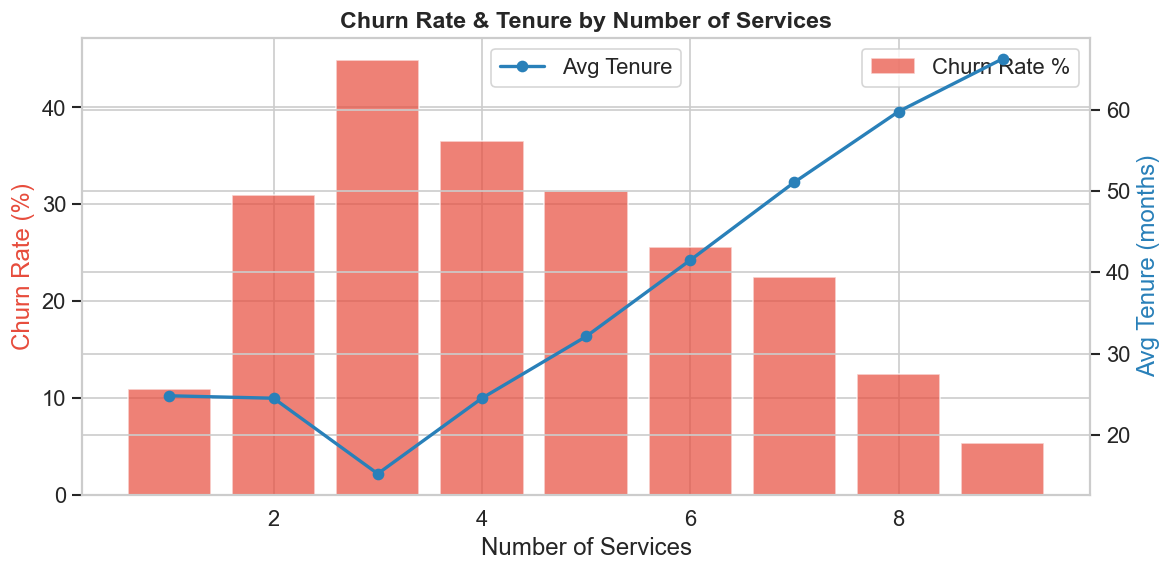

📌 Insight: More services = lower churn + longer tenure. Cross-sell is key.


In [11]:
df8 = run_query('../queries/08_churn_by_num_services.sql')
display(df8)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
ax1.bar(df8['num_services'], df8['churn_rate_pct'], color='#e74c3c', alpha=0.7, label='Churn Rate %')
ax2.plot(df8['num_services'], df8['avg_tenure_months'], color='#2980b9', marker='o', linewidth=2, label='Avg Tenure')
ax1.set_title('Churn Rate & Tenure by Number of Services', fontsize=14, fontweight='bold')
ax1.set_xlabel('Number of Services')
ax1.set_ylabel('Churn Rate (%)', color='#e74c3c')
ax2.set_ylabel('Avg Tenure (months)', color='#2980b9')
ax1.legend(loc='upper right')
ax2.legend(loc='upper center')
plt.tight_layout()
plt.savefig('../docs/sql_services_vs_churn.png', bbox_inches='tight')
plt.show()
print('📌 Insight: More services = lower churn + longer tenure. Cross-sell is key.')

## Q9 — Demographics <a id='10'></a>

In [12]:
df9 = run_query('../queries/09_churn_by_demographics.sql')
display(df9.sort_values('churn_rate_pct', ascending=False))
print('📌 Insight: Senior citizens without dependents or partners are the highest-risk demographic.')

,customer_segment,dependents,partner_status,total_customers,churned,churn_rate_pct,avg_monthly_charge
0,Senior,No Dependents,No Partner,561,276,49.20,76.86
1,Senior,No Dependents,Has Partner,490,178,36.33,82.75
2,Non-Senior,No Dependents,No Partner,2719,847,31.15,60.12
3,Senior,Has Dependents,No Partner,8,2,25.00,75.42
4,Senior,Has Dependents,Has Partner,83,20,24.10,82.95
5,Non-Senior,Has Dependents,No Partner,353,75,21.25,51.99
6,Non-Senior,No Dependents,Has Partner,1163,242,20.81,71.70
7,Non-Senior,Has Dependents,Has Partner,1666,229,13.75,59.87


📌 Insight: Senior citizens without dependents or partners are the highest-risk demographic.


## Q10 — Executive Summary KPI Report <a id='11'></a>

In [14]:
df10 = run_query('../queries/10_executive_summary.sql')
print('📊 EXECUTIVE SUMMARY — Customer Churn KPI Report')
print('=' * 50)
for _, row in df10.iterrows():
    print(f"{row['metric']:<40} {row['value']}")

📊 EXECUTIVE SUMMARY — Customer Churn KPI Report
OVERALL                                  
Total Customers                          7043
Total Churned                            1869
Overall Churn Rate                       26.54%
Monthly Revenue at Risk ($)              139131.0
HIGHEST RISK SEGMENTS                    
Worst Contract Type                      Month-to-month - 42.7% churn
Worst Tenure Group                       0-12 months - 47.4% churn
Worst Payment Method                     Electronic check - 45.3% churn
REVENUE                                  
Avg Charge - Churned ($)                 74.44
Avg Charge - Retained ($)                61.27
Total Monthly Revenue ($)                456117.0


---
## 💡 Final Business Recommendations

| Priority | Action | Target Segment | Expected Impact |
|---|---|---|---|
| 🔴 High | Onboarding programme | 0–12 month customers | Reduce early churn by ~15% |
| 🔴 High | Annual plan incentive | Month-to-month customers | Cut churn from 42% → ~20% |
| 🟠 Medium | Tech Support upsell | Fiber optic, no support | Halve churn in this segment |
| 🟠 Medium | Auto-pay switch discount | Electronic check users | Reduce churn by ~10% |
| 🟡 Low | Cross-sell services | 1–2 service customers | Increase stickiness |

**Next Step → Phase 2:** Build an XGBoost model to predict churn probability per customer 🚀